In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline

from mnist_lipschitz.adversarial import strong_cnn_experiment
from mnist_lipschitz.adversarial import run_experiment
from mnist_lipschitz.adversarial import plots as adv_plots
from mnist_lipschitz.adversarial.run_experiment import most_and_least_sensitive_examples, FlattenedInputWrapper
from mnist_lipschitz.adversarial.strong_cnn_experiment import strong_cnn_head_layer_bound_check
from mnist_lipschitz.estimators import euclidean_distance_fn


# Adversarial Perturbation vs. Lipschitz Bound (StrongCNN)

## Motivation

`notebook_adversarial_lipschitz.ipynb` (sibling notebook) runs this same comparison for
`SmallCNN`: generate real FGSM/PGD adversarial examples against a trained checkpoint, and check
whether their achieved sensitivity ratio sits close to a TIGHT Lipschitz bound
(`L_full_estimated`, the network's own empirical Lipschitz constant) or the LOOSE per-layer
submultiplicative bound (`product_bound = L_extractor_estimated * L_head_exact`, Szegedy et al.
2014).

This notebook repeats that comparison for `StrongCNN` (`models.py`) -- the project's
higher-capacity, near-state-of-the-art baseline (BatchNorm, dropout, light augmentation, ~99.3%+
test-accuracy target) -- with two structural differences from the SmallCNN version, both handled
in the sibling module `strong_cnn_experiment.py` (not by modifying `models.py` or
`layer_decomposition.py`):

1. **`StrongCNN` has no `.extractor`/`.head` submodule split.** Its final classifier layer
   (`model.classifier[4]`) IS a plain `nn.Linear` with nothing nonlinear after it, so the same
   tight/loose bound comparison is still possible via an EXTERNALLY-constructed extractor/head
   split (`strong_cnn_extractor_fn` = `model.features` + `model.classifier[:4]`,
   `strong_cnn_head_module` = `model.classifier[4]`).
2. **`StrongCNN` has `BatchNorm1d`/`Dropout2d`/`Dropout` layers `SmallCNN` never had**, which
   makes `model.eval()` mode non-optional for every downstream computation (bound estimation AND
   attacks) to be well-defined -- `strong_cnn_experiment.py`'s functions RAISE `ValueError`
   rather than silently fixing this if the model is left in train mode; see that module's
   docstring.

**Scope: baseline only.** No CNN-width sweep (`StrongCNN`'s conv channels are hardcoded, not a
constructor parameter, unlike `SmallCNN`'s) and no multi-seed pilot (`seed_sweep.py`'s pattern,
also `SmallCNN`-specific) -- both deliberately out of scope here.

**`max_R_adv` is still a LOWER BOUND on the network's true worst-case sensitivity**, exactly as in
the SmallCNN notebook -- FGSM/PGD maximize cross-entropy loss, not `R_adv` directly. Results
throughout are "achieved under this attack," never "the" worst case.

**Weaker checkpoint-gating than the SmallCNN machinery**: `strong_cnn_experiment.py`'s central
correctness check (`tests/test_strong_cnn_experiment.py`) is a SELF-consistency check (does
`compute_strong_cnn_bounds` reduce to a from-scratch manual computation using the same closures),
not a check against an independently-existing reference the way `compute_bounds_with_distance_fn`
checks against `layer_decomposition_experiment` for SmallCNN -- no such reference exists for
StrongCNN, since `layer_decomposition.py` was deliberately never extended to it.


## Baseline checkpoint: train, then compare against both bounds

`strong_cnn_experiment.main()` trains ONE `StrongCNN` via `STRONG_CNN_CONFIG`'s exact recipe
(full 60k MNIST, 25 epochs, light rotation/translation augmentation, cosine-annealed learning
rate -- the SAME recipe `mnist_lipschitz.run_experiment.run_stronger_cnn_raw_mnist_experiment`
uses elsewhere in this project), then runs the full epsilon sweep and tight/loose bound
comparison against it. The checkpoint is cached to `results/strong_cnn_state_dict.pt` -- the
Mahalanobis section below reuses the SAME weights rather than retraining (training doesn't
depend on `distance_fn`, exactly as in the SmallCNN notebook's Euclidean/Mahalanobis reuse).


In [2]:
summary_df, sweep_results, strong_cnn_model = strong_cnn_experiment.main(
    distance_fn=euclidean_distance_fn, seed=0, verbose=True)


[checkpoint] loaded StrongCNN from /Users/yichaowang/Documents/Part A/Datasig project/code/mnist_lipschitz/adversarial/results/strong_cnn_state_dict.pt (train_acc=0.9981  test_acc=0.9966)


  [distance_fn='euclidean_distance_fn'] L_head_exact=2.1049  L_extractor_est=3.8383  L_full_est=5.7157  looseness_ratio=1.4135


filter_correctly_classified: kept 0.9975 of the pool (1995/2000 points)


  epsilon=0.05  FGSM  mean_R_adv=12.4181  max_R_adv=17.6496  pct_misclassified=0.2040


  epsilon=0.05  PGD   mean_R_adv=16.1101  max_R_adv=24.0739  pct_misclassified=0.6700


...

  epsilon=0.15  PGD   mean_R_adv=10.2923  max_R_adv=13.7822  pct_misclassified=1.0000


  epsilon=0.2  FGSM  mean_R_adv=4.9630  max_R_adv=6.8619  pct_misclassified=0.8700


  epsilon=0.2  PGD   mean_R_adv=9.2427  max_R_adv=12.3095  pct_misclassified=1.0000


  epsilon=0.25  FGSM  mean_R_adv=4.1662  max_R_adv=5.8311  pct_misclassified=0.9440


  epsilon=0.25  PGD   mean_R_adv=8.5764  max_R_adv=11.3907  pct_misclassified=1.0000
 epsilon method  mean_R_adv  median_R_adv  max_R_adv  pct_misclassified  L_full_estimated  product_bound  ratio_to_L_full  ratio_to_product_bound
    0.05   FGSM   12.418053     12.587750  17.649577              0.204           5.71569       8.079263         3.087917                2.184553
    0.10   FGSM    8.233764      8.278780  11.257876              0.546           5.71569       8.079263         1.969644                1.393429
    0.15   FGSM    6.171678      6.197304   8.466104              0.766           5.71569       8.079263         1.481204                1.047881
    0.20   FGSM    4.963021      4.970105   6.861903              0.870           5.71569       8.079263         1.200538                0.849323
    0.25   FGSM    4.166152      4.186907   5.831077              0.944           5.71569       8.079263         1.020188                0.721734
    0.05    PGD   16.110122     16.0853

**What to look for**: same columns as the SmallCNN notebook's baseline table
(`mean_R_adv`/`median_R_adv`/`max_R_adv`, `pct_misclassified`, `L_full_estimated`,
`product_bound`, `ratio_to_L_full`, `ratio_to_product_bound`) -- see that notebook's own "What to
look for" cell for the full explanation of each column. A
`WARNING: max_R_adv > L_full_estimated` print (if any) means `L_full_estimated` under-sampled
(too few pairs/query points), not a real bound violation -- same caveat as always.


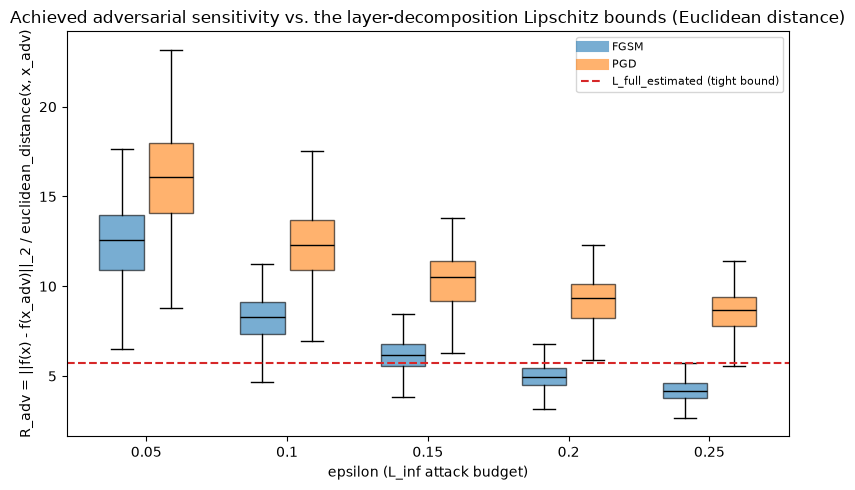

In [3]:
wrapped_strong_cnn = FlattenedInputWrapper(strong_cnn_model)

fig_R_adv_eucl = adv_plots.plot_R_adv_distribution(
    sweep_results, summary_df["L_full_estimated"].iloc[0], summary_df["product_bound"].iloc[0],
    metric_name="Euclidean",
    save_path=run_experiment.RESULTS_DIR / "strong_cnn_R_adv_distribution_euclidean.png")


## Most and least sensitive attacked example

Across every `(epsilon, method)` case in the sweep above: the single attacked point that
achieved the LARGEST `R_adv` and the single one that achieved the SMALLEST `R_adv`, each
extended with `strong_cnn_head_layer_bound_check`'s feature-space-distance-vs-head-Lipschitz-
bound comparison for that specific example -- same idea as
`run_experiment.head_layer_bound_check` for SmallCNN, just using `strong_cnn_experiment`'s
externally-constructed extractor/head split.


In [4]:
most_sensitive, least_sensitive = most_and_least_sensitive_examples(wrapped_strong_cnn, sweep_results)
most_sensitive.update(strong_cnn_head_layer_bound_check(strong_cnn_model, most_sensitive))
least_sensitive.update(strong_cnn_head_layer_bound_check(strong_cnn_model, least_sensitive))

for label, example in (("most sensitive ", most_sensitive), ("least sensitive", least_sensitive)):
    print(f"{label}: R_adv={example['R_adv']:.4f}  eps={example['epsilon']:g} {example['method']}  "
          f"true={example['y_true']}  pred_clean={example['pred_clean']}  pred_adv={example['pred_adv']}")
    print(f"    pixel_distance={example['pixel_distance']:.4f}  "
          f"feature_distance={example['feature_distance']:.4f}  "
          f"L_head_exact={example['L_head_exact']:.4f}  head_bound={example['head_bound']:.4f}  "
          f"actual={example['actual_logit_distance']:.4f}  "
          f"({example['head_bound_tightness']:.1%} of bound)")


most sensitive : R_adv=24.0739  eps=0.05 PGD  true=5  pred_clean=5  pred_adv=9
    pixel_distance=0.8633  feature_distance=12.5480  L_head_exact=2.5997  head_bound=32.6214  actual=20.7833  (63.7% of bound)
least sensitive: R_adv=2.3200  eps=0.25 FGSM  true=2  pred_clean=2  pred_adv=7
    pixel_distance=5.3244  feature_distance=9.1771  L_head_exact=2.5997  head_bound=23.8579  actual=12.3527  (51.8% of bound)


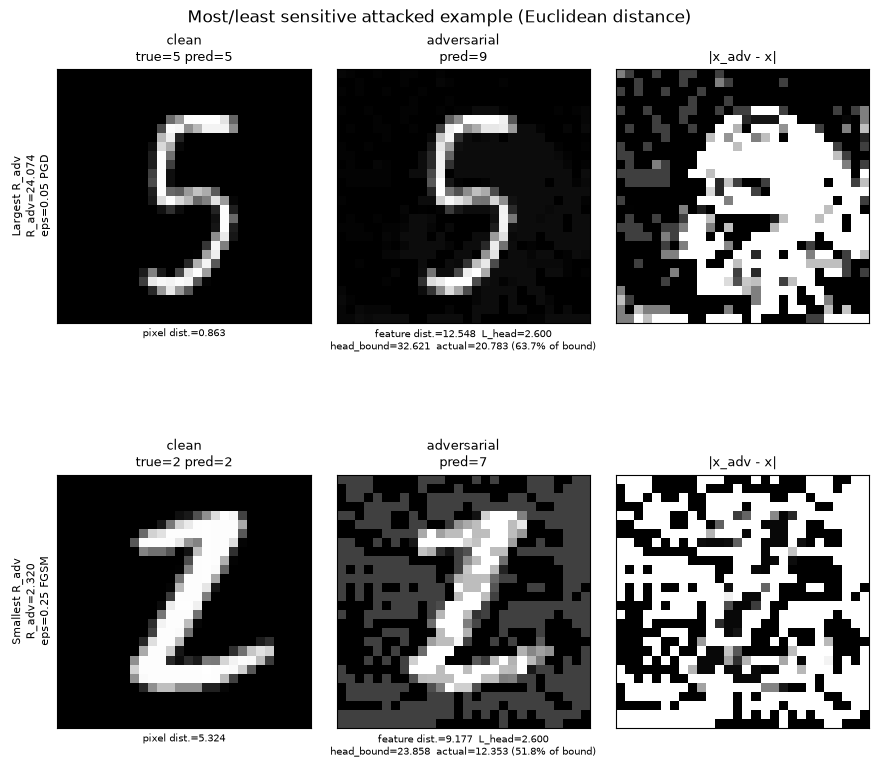

In [5]:
fig_extreme_eucl = adv_plots.plot_extreme_examples(
    most_sensitive, least_sensitive, metric_name="Euclidean",
    save_path=run_experiment.RESULTS_DIR / "strong_cnn_extreme_examples_euclidean.png")


# Repeating the Experiment with Mahalanobis Distance

Same construction as the SmallCNN notebook's own Euclidean-vs-Mahalanobis section: a
ridge-regularized Mahalanobis distance fit from MNIST's own pixel covariance
(`run_experiment.build_pixel_mahalanobis_distance_fn`, `epsilon=0.01`, the same established
choice used throughout this project -- see `mnist_lipschitz/README.md`'s "Epsilon selection"
section for why).


In [6]:
train = run_experiment.load_mnist(train=True)
mahalanobis_distance_fn = run_experiment.build_pixel_mahalanobis_distance_fn(train.x_flat)


## Baseline checkpoint (Mahalanobis)

`strong_cnn_experiment.main(distance_fn=mahalanobis_distance_fn)` reuses the SAME trained
checkpoint as the Euclidean section above (loaded from `results/strong_cnn_state_dict.pt`,
matching `seed=0` -- no retraining) and the SAME adversarial examples (attacks don't depend on
`distance_fn`, see `run_epsilon_sweep`'s own docstring) -- only how sensitivity is MEASURED
differs.


In [7]:
summary_df_mahalanobis, sweep_results_mahalanobis, _ = strong_cnn_experiment.main(
    distance_fn=mahalanobis_distance_fn, seed=0, verbose=True)


[checkpoint] loaded StrongCNN from /Users/yichaowang/Documents/Part A/Datasig project/code/mnist_lipschitz/adversarial/results/strong_cnn_state_dict.pt (train_acc=0.9981  test_acc=0.9966)


  [distance_fn='<lambda>'] L_head_exact=2.1049  L_extractor_est=1.6380  L_full_est=2.5079  looseness_ratio=1.3748


filter_correctly_classified: kept 0.9975 of the pool (1995/2000 points)


  epsilon=0.05  FGSM  mean_R_adv=1.8333  max_R_adv=2.7584  pct_misclassified=0.2040


  epsilon=0.05  PGD   mean_R_adv=2.6137  max_R_adv=4.5675  pct_misclassified=0.6700


...

  epsilon=0.15  PGD   mean_R_adv=1.6529  max_R_adv=2.4544  pct_misclassified=1.0000


  epsilon=0.2  FGSM  mean_R_adv=0.7302  max_R_adv=1.0308  pct_misclassified=0.8700


  epsilon=0.2  PGD   mean_R_adv=1.4546  max_R_adv=2.0969  pct_misclassified=1.0000


  epsilon=0.25  FGSM  mean_R_adv=0.6124  max_R_adv=0.8629  pct_misclassified=0.9440


  epsilon=0.25  PGD   mean_R_adv=1.3244  max_R_adv=1.8571  pct_misclassified=1.0000
 epsilon method  mean_R_adv  median_R_adv  max_R_adv  pct_misclassified  L_full_estimated  product_bound  ratio_to_L_full  ratio_to_product_bound
    0.05   FGSM    1.833293      1.824738   2.758431              0.204          2.507923       3.447827         1.099887                0.800049
    0.10   FGSM    1.213627      1.198428   1.739292              0.546          2.507923       3.447827         0.693519                0.504460
    0.15   FGSM    0.908828      0.899944   1.285510              0.766          2.507923       3.447827         0.512580                0.372846
    0.20   FGSM    0.730196      0.727476   1.030841              0.870          2.507923       3.447827         0.411034                0.298983
    0.25   FGSM    0.612424      0.610829   0.862899              0.944          2.507923       3.447827         0.344069                0.250273
    0.05    PGD    2.613684      2.53370

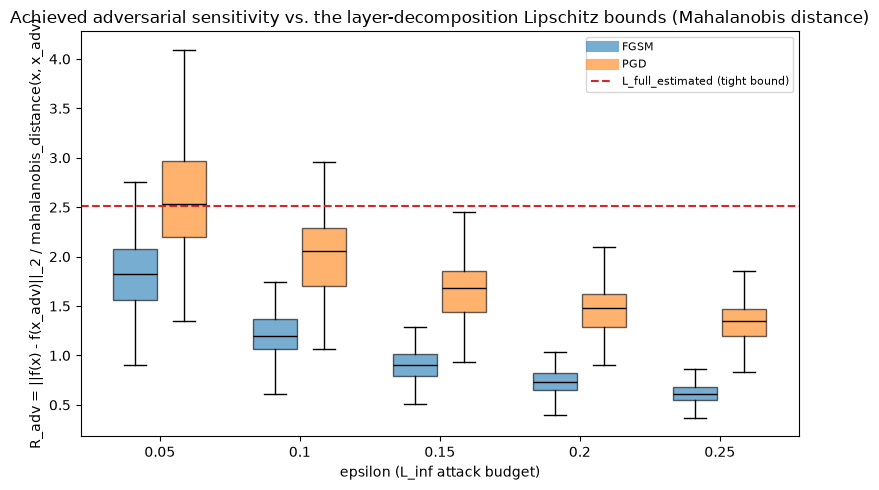

In [8]:
fig_R_adv_maha = adv_plots.plot_R_adv_distribution(
    sweep_results_mahalanobis, summary_df_mahalanobis["L_full_estimated"].iloc[0],
    summary_df_mahalanobis["product_bound"].iloc[0], metric_name="Mahalanobis",
    save_path=run_experiment.RESULTS_DIR / "strong_cnn_R_adv_distribution_mahalanobis.png")


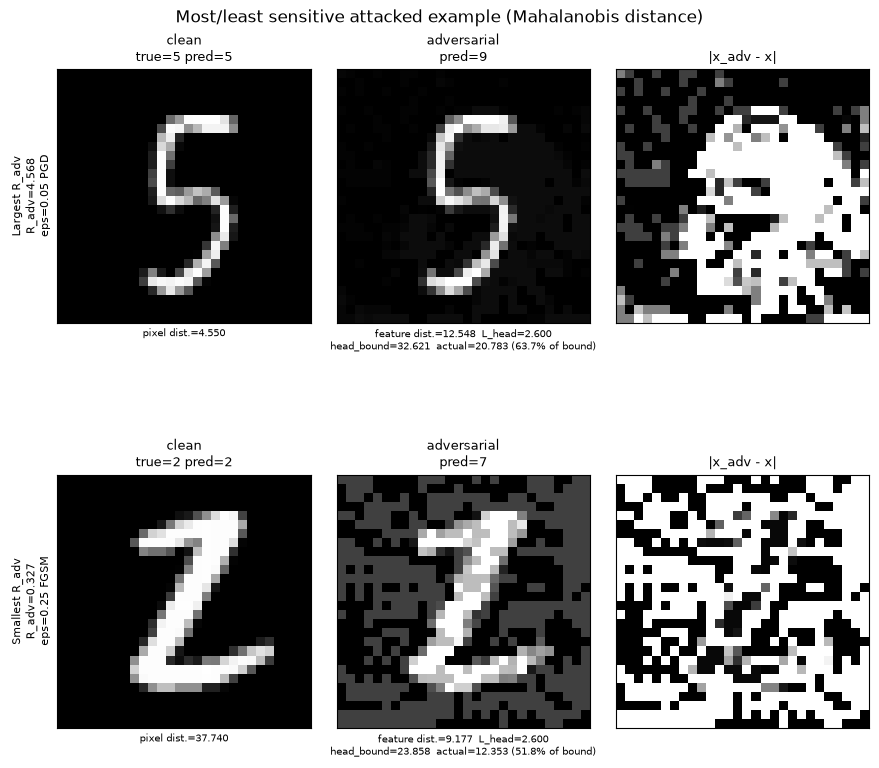

In [9]:
most_sensitive_maha, least_sensitive_maha = most_and_least_sensitive_examples(
    wrapped_strong_cnn, sweep_results_mahalanobis, distance_fn=mahalanobis_distance_fn)
most_sensitive_maha.update(strong_cnn_head_layer_bound_check(strong_cnn_model, most_sensitive_maha))
least_sensitive_maha.update(strong_cnn_head_layer_bound_check(strong_cnn_model, least_sensitive_maha))

fig_extreme_maha = adv_plots.plot_extreme_examples(
    most_sensitive_maha, least_sensitive_maha, metric_name="Mahalanobis",
    save_path=run_experiment.RESULTS_DIR / "strong_cnn_extreme_examples_mahalanobis.png")


## Comparison: Euclidean vs. Mahalanobis

Both metrics were run against the SAME checkpoint and the SAME adversarial examples throughout
(see the section intro above) -- so any difference below reflects only how "distance" is
measured, not a confound from different models or different attacks.


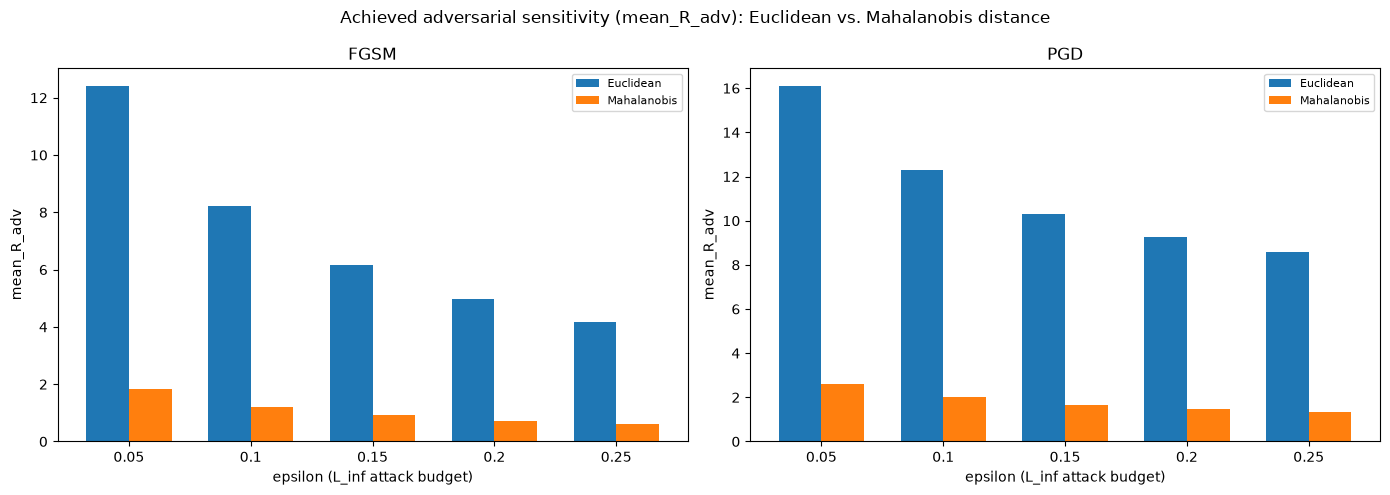

In [10]:
fig_cmp = adv_plots.plot_euclidean_vs_mahalanobis_R_adv(
    summary_df, summary_df_mahalanobis,
    save_path=run_experiment.RESULTS_DIR / "strong_cnn_euclidean_vs_mahalanobis_R_adv.png")


## Summary and status

See the printed tables and plots above for the actual measured numbers (they vary run to run
with the random seed and aren't restated here to avoid this notebook silently going stale
against its own output -- re-run the cells above for the current numbers).

**Design decisions**:
- `strong_cnn_experiment.py` reuses `attacks.py`, `plots.py`, and every architecture-agnostic
  function in `run_experiment.py` (`run_epsilon_sweep`, `summarize_epsilon_sweep`,
  `most_and_least_sensitive_examples`, ...) UNCHANGED -- only the extractor/head split and the
  bound-computation/training driver are StrongCNN-specific.
- `model.eval()` discipline is enforced by RAISING, not silently fixed -- see
  `strong_cnn_experiment.py`'s module docstring.
- No CNN-width sweep or multi-seed pilot -- out of scope (see the Motivation cell above).

**Explicitly out of scope, not attempted**: any capacity/width sweep for StrongCNN (no width
parameter exists); a multi-seed confirmation sweep (`seed_sweep.py`'s pattern); Carlini-Wagner or
other attack methods (FGSM/PGD only, same as the SmallCNN notebook); adversarial training or any
other mitigation.


## Findings and observations (seed=0 run)

The "Summary and status" section above deliberately avoids restating numbers to stay from going
stale. This section is the exception: it records what a specific run (`seed=0`, `train_acc=0.9981`,
`test_acc=0.9966`) actually showed, as a snapshot -- re-run and compare rather than trusting these
figures blind if the code has since changed.

### Baseline bounds

`L_head_exact=2.105` (identical between metrics, by construction -- confirmed directly: the head
maps extracted features, always Euclidean, to logits, always Euclidean; only the pixel-space side
is pluggable).

| Metric | `L_extractor_est` | `L_full_estimated` | `product_bound` | `looseness_ratio` |
|---|---|---|---|---|
| Euclidean | 3.838 | 5.716 | 8.079 | 1.41x |
| Mahalanobis | 1.638 | 2.508 | 3.448 | 1.37x |

`looseness_ratio` is far tighter than SmallCNN's baseline (16.4x under Euclidean) -- StrongCNN's
much deeper extractor (6 conv/BatchNorm layers + a 256-d FC layer, vs. SmallCNN's 2 conv layers)
apparently makes the per-layer submultiplicative bound a much closer approximation to the
network's actual end-to-end sensitivity, at least at this query-sample size.

### A much more severe tight-bound gap than SmallCNN ever showed

**Under Euclidean distance, `max_R_adv` exceeds `L_full_estimated` at EVERY SINGLE epsilon/method
combination tested** (`ratio_to_L_full` from 1.02x up to 4.21x) -- not the occasional, mild
(~1.00-1.02x) graze SmallCNN's baseline showed. `summarize_epsilon_sweep`'s sanity-check warning
fires on all but one row. This is still consistent with `L_full_estimated` being a valid LOWER
BOUND from a finite, RANDOMLY-sampled 200-point query set (not a real violation of any
mathematical guarantee) -- but the magnitude here suggests something more specific: with only 200
natural (non-adversarial) query points in 784-d pixel space, `pairwise_lipschitz`'s exhaustive
scoring over ~19,900 random pairs is very unlikely to land anywhere near the sharp, localized
sensitivity directions PGD's targeted, iterative gradient search can find -- and StrongCNN's
higher capacity/depth plausibly has MORE such sharp directions than SmallCNN's shallower network,
making random-pair sampling a much weaker proxy for its true worst-case sensitivity.

**Under Mahalanobis distance, the same gap is dramatically smaller, and the tight bound is not
even exceeded for most FGSM rows** (`ratio_to_L_full` ranges `0.34x-1.82x`, vs. Euclidean's
`1.02x-4.21x` at the same epsilons) -- the OPPOSITE pattern from the SmallCNN width sweep, where
Mahalanobis distance was found to WIDEN the gap between achieved sensitivity and both bounds, not
narrow it (see `notebook_adversarial_lipschitz.ipynb`'s own findings). Why the direction of this
effect flips between the two architectures is not established here -- worth investigating
directly (e.g. whether it's driven by StrongCNN's much larger `L_extractor_estimated` gap between
metrics, `3.838` vs. `1.638`, a ~2.3x difference vs. SmallCNN's comparatively smaller metric gap
at its default width).

### Most/least sensitive example (Euclidean)

The single largest-`R_adv` example (`R_adv=24.07`, `epsilon=0.05` PGD, true digit 5 flipped to
predicted 9) reaches only **63.7%** of the head layer's own exact Cauchy-Schwarz bound
(`actual_logit_distance / head_bound`) -- meaning even the most-effective real attack found here
doesn't max out the (always-tight, exact) head-layer bound; the "excess" over `L_full_estimated`
traces to the extractor/pixel-to-feature portion of the network being far more sensitive along
this PGD-found direction than the random query-point pairs happened to reveal, not to any part of
the pipeline being mismeasured.

## Status

**Confirmed working:** all 18 `tests/test_strong_cnn_experiment.py` tests pass, including the
composition-identity check (`strong_cnn_head_module(model)(strong_cnn_extractor_fn(model,x,y))
== model(x)` exactly), the eval-mode-matters checks (BatchNorm's train-mode batch-dependence
confirmed directly; every StrongCNN-specific function raises `ValueError` if called with
`model.training=True`), and the self-consistency parity check. This notebook executes end to end
with zero errors; total standalone wall-clock time for `main()`'s first (training) call was
~19.7 minutes on CPU (~18 min training StrongCNN's `STRONG_CNN_CONFIG` recipe -- 25 epochs, full
60k MNIST, augmentation -- plus ~100s for the bound comparison and full FGSM/PGD sweep); the
notebook's own two `main()` calls both hit the cached checkpoint and ran in a small fraction of
that.

**Explicitly out of scope, not attempted:** any CNN-capacity/width sweep for StrongCNN (its conv
channels are hardcoded, not a constructor parameter, unlike `SmallCNN`'s); a multi-seed
confirmation sweep (`seed_sweep.py`'s pattern, also `SmallCNN`-specific); Carlini-Wagner or other
attack methods (FGSM/PGD only); adversarial training or any other mitigation.

**Worth revisiting:**
- **Why the Euclidean-vs-Mahalanobis gap-width effect flips direction between StrongCNN and
  SmallCNN is not established** (see above) -- the single most interesting open question from
  this run.
- **Only `n_query_points=200` was used for the Lipschitz-bound estimate** (matching this
  notebook's baseline default, same as SmallCNN's) -- given how much `max_R_adv` exceeds
  `L_full_estimated` here, a larger query sample might substantially tighten `L_full_estimated`
  for StrongCNN specifically; not tested.
- **This is a single-seed run** -- whether the ~1.4x `looseness_ratio` or the
  Euclidean/Mahalanobis gap-width reversal are stable across seeds is unknown.
